![Alt text](https://imgur.com/orZWHly.png=80)
source: @allison_horst https://github.com/allisonhorst/penguins

You have been asked to support a team of researchers who have been collecting data about penguins in Antartica! The data is available in csv-Format as `penguins.csv`

**Origin of this data** : Data were collected and made available by Dr. Kristen Gorman and the Palmer Station, Antarctica LTER, a member of the Long Term Ecological Research Network.

**The dataset consists of 5 columns.**

Column | Description
--- | ---
culmen_length_mm | culmen length (mm)
culmen_depth_mm | culmen depth (mm)
flipper_length_mm | flipper length (mm)
body_mass_g | body mass (g)
sex | penguin sex

Unfortunately, they have not been able to record the species of penguin, but they know that there are **at least three** species that are native to the region: **Adelie**, **Chinstrap**, and **Gentoo**.  Your task is to apply your data science skills to help them identify groups in the dataset!

In [15]:
# Import Required Packages
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Loading and examining the dataset
penguins_df = pd.read_csv("penguins.csv")
penguins_df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,36.7,19.3,193.0,3450.0,FEMALE
4,39.3,20.6,190.0,3650.0,MALE


In [16]:
#Examine the dataframe
penguins_df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,332.000000,332.000000,332.000000,332.000000
mean,44.021084,17.153012,200.975904,4206.475904
std,5.452462,1.960275,14.035971,806.361278
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.700000,17.300000,197.000000,4025.000000
75%,48.625000,18.700000,213.000000,4781.250000
max,59.600000,21.500000,231.000000,6300.000000


In [17]:
penguins_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   332 non-null    float64
 1   culmen_depth_mm    332 non-null    float64
 2   flipper_length_mm  332 non-null    float64
 3   body_mass_g        332 non-null    float64
 4   sex                332 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.1+ KB


In [18]:
#check the values of the categorical feature
print(penguins_df['sex'].unique())
print(penguins_df['sex'].nunique())

print(penguins_df['sex'].value_counts())

['MALE' 'FEMALE']
2
MALE      167
FEMALE    165
Name: sex, dtype: int64


In [19]:
#encode categorical feature
penguins_df = pd.get_dummies(penguins_df, columns=['sex'])
penguins_df.head(10)

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex_FEMALE,sex_MALE
0,39.1,18.7,181.0,3750.0,0,1
1,39.5,17.4,186.0,3800.0,1,0
2,40.3,18.0,195.0,3250.0,1,0
3,36.7,19.3,193.0,3450.0,1,0
4,39.3,20.6,190.0,3650.0,0,1
5,38.9,17.8,181.0,3625.0,1,0
6,39.2,19.6,195.0,4675.0,0,1
7,41.1,17.6,182.0,3200.0,1,0
8,38.6,21.2,191.0,3800.0,0,1
9,36.6,17.8,185.0,3700.0,1,0


In [20]:
#Scale the data
scaler = StandardScaler()
scaled_df = scaler.fit_transform(penguins_df)
type(scaled_df)

numpy.ndarray

In [21]:
import numpy as np
print(f"df mean: {np.mean(scaled_df)}")
print(f"df std: {np.std(scaled_df)}")

df mean: 7.713597721291248e-17
df std: 1.0


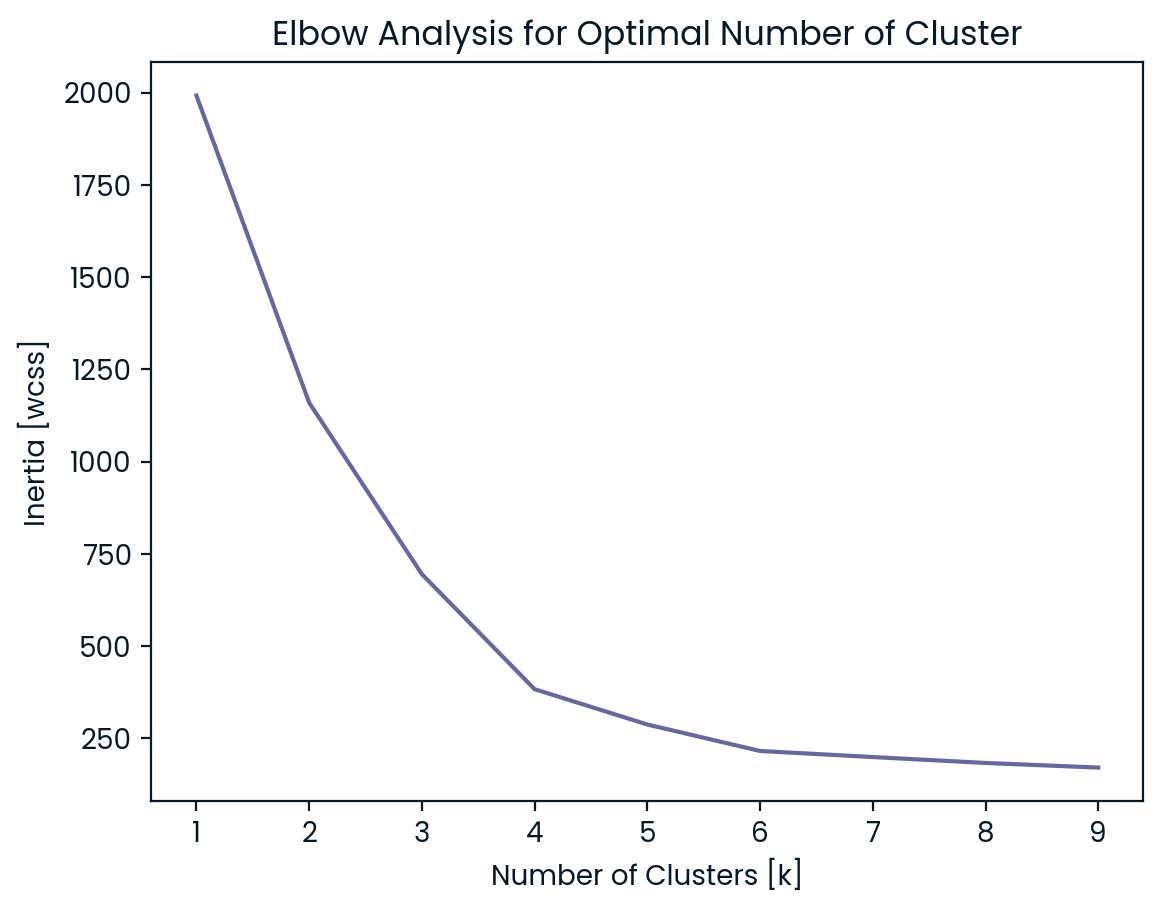

In [22]:
#determine the optimal number of clusters
inertia = []

for k in range(1,10):
    model= KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_df)
    inertia.append(model.inertia_)

plt.plot(range(1, 10), inertia)
plt.title('Elbow Analysis for Optimal Number of Cluster')
plt.xlabel('Number of Clusters [k]')
plt.ylabel('Inertia [wcss]')
plt.show()

In [23]:
#create a model with the optimal cluster
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(scaled_df)

KMeans(n_clusters=4, random_state=42)

In [24]:
labels = kmeans.labels_

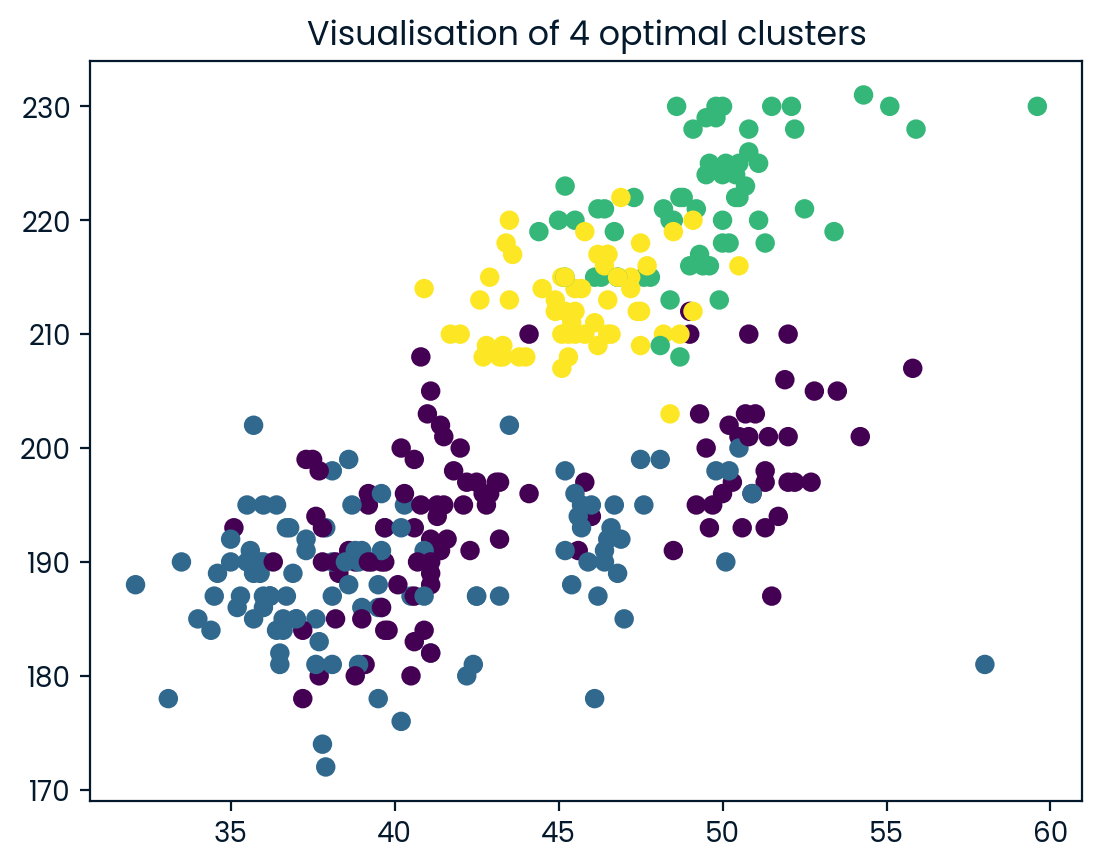

In [25]:
#vidualize the clusters
plt.scatter(penguins_df['culmen_length_mm'], penguins_df['flipper_length_mm'], c=labels)
plt.title("Visualisation of 4 optimal clusters")
plt.show()

In [26]:
#Create a dataframe for submission.

#get numeric columns
numeric_columns = [
    col for col in penguins_df.select_dtypes(include = 'number').columns if penguins_df[col].nunique() > 2
]
numeric_columns

['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']

In [27]:
#create a label column
penguins_df['label'] = kmeans.labels_

#create a stat_penguin dataframe
stat_penguins = penguins_df.groupby('label')[numeric_columns].mean()
stat_penguins

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
label,,,,
0,43.878302,19.111321,194.764151,4006.603774
1,40.217757,17.611215,189.046729,3419.158879
2,49.473770,15.718033,221.540984,5484.836066
3,45.563793,14.237931,212.706897,4679.741379
